# 202 — Probability-weighted transmissivity uncertainty cost

**Purpose:** This notebook takes the validated baseline fish-dollars Pareto designs and evaluates the hydrologic effect of an **unknown transmissivity uncertainty distribution**.

The workflow is:

1. Use the same baseline Pareto-front pumping designs validated in notebook `200` and evaluated in notebook `201`.
2. Treat the baseline transmissivity as the assumed-correct value.
3. Define a normal distribution of possible true transmissivity values around the baseline T.
4. Re-evaluate every baseline Pareto design under each sampled T value.
5. Calculate probability-weighted hydrologic cost metrics.

Main hydrologic metrics:

- **Total pumping** = fixed pumping design from the baseline Pareto member.
- **Depletion** = `lpr:total_combined:bdpl` from PyCap.
- **Streamflow** = historic/reference streamflow minus depletion.
- **Probability-weighted absolute streamflow error** = expected magnitude of streamflow prediction error due to T uncertainty.
- **Probability-weighted streamflow shortfall** = expected one-sided loss where true streamflow is lower than the baseline-T assumption.

The fish-dollars objectives are still saved as diagnostics, but this notebook focuses on pumping, depletion, and streamflow.

## 1) User settings

Run this notebook from:

`/workspaces/LPR_redux/LPR_pycap_opt/notebooks`

Only edit this first code cell if you want to change the uncertainty distribution or run a smaller smoke test.

In [1]:
from pathlib import Path
import sys
import os
import copy
import importlib.util
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User settings
# -----------------------------
RUN_NAME = "fish_dollars_baseline_0.0_1.0_0.01"

# Use all final-generation feasible front-1 members by default.
# To make a fast smoke test, set N_TEST_MEMBERS = 5 or 10.
N_TEST_MEMBERS = None

# Conversion used in older postprocessing notebooks for pumping diagnostics.
GPM2CFS = 0.002228

# Hydrologic tradeoff settings for this project.
HISTORIC_STREAMFLOW_CFS = 8.6
DEPLETION_OBS_NAME = "lpr:total_combined:bdpl"

# Main x-axis for hydrologic plots.
# Because the fish-dollars forward model shuts down farms/wells below the 70% threshold,
# the effective pumping is the pumping actually passed through the objective calculation.
PUMPING_COLUMN_FOR_HYDRO_PLOTS = "effective_total_pumping_cfs"

# -----------------------------
# Transmissivity uncertainty distribution
# -----------------------------
# T is treated as normally distributed about the baseline value.
# A 0.10 relative standard deviation means sigma_T = 10% of baseline T.
T_RELATIVE_SIGMA = 0.10

# Evaluate 5 values below and 5 values above baseline T, plus the baseline value itself.
N_T_VALUES_EACH_SIDE = 5

# +/- 2 standard deviations gives a compact but useful uncertainty sweep.
N_SIGMA_EACH_SIDE = 2.0

# Optional management threshold for streamflow-risk calculations.
# Leave as None if you only want cost relative to the baseline-T streamflow prediction.
STREAMFLOW_THRESHOLD_CFS = None

# If True and the long output CSV already exists, the notebook loads it instead of re-running PyCap.
# First run should usually be True for RUN_FORWARD_MODELS.
RUN_FORWARD_MODELS = True

# -----------------------------
# Robust repo paths
# -----------------------------
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
RUN_DIR = PROJECT_DIR / "pycap_runs" / "pycap_pest" / f"run_{RUN_NAME}"
SCRIPTS_DIR = PROJECT_DIR / "scripts"
OUTPUT_DIR = NOTEBOOK_DIR / "project_output" / "202_probability_weighted_T_uncertainty_cost"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("RUN_DIR:", RUN_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

NOTEBOOK_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
RUN_DIR: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost


## 2) Load the original fish-dollars forward model

We keep using the original fish-dollars forward script as the source of truth. Even though this notebook analyzes hydrologic outputs, the script is still important because it applies the same pumping-design logic used in the original optimization, especially the 70% pumping cutoff.

In [2]:
def import_python_file(module_name: str, file_path: Path):
    """Import a Python file by path without permanently changing the repo."""
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find Python file: {file_path}")
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


# Prefer the copy inside the run folder because that is exactly what the MOU run used.
# Fall back to ../scripts if needed.
candidate_scripts = [
    RUN_DIR / "run_pycap_standalone_opt_mou_fish_dollars.py",
    SCRIPTS_DIR / "run_pycap_standalone_opt_mou_fish_dollars.py",
]

for candidate in candidate_scripts:
    if candidate.exists():
        FISH_DOLLARS_SCRIPT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find run_pycap_standalone_opt_mou_fish_dollars.py "
        "in the run folder or scripts folder."
    )

fish_dollars = import_python_file("fish_dollars_forward_202", FISH_DOLLARS_SCRIPT)
print("Using fish-dollars source-of-truth script:")
print(FISH_DOLLARS_SCRIPT)

Using fish-dollars source-of-truth script:
/workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01/run_pycap_standalone_opt_mou_fish_dollars.py


## 3) Helper functions

In [3]:
def read_pareto_archive_summary(run_name: str, run_dir: Path) -> pd.DataFrame:
    pareto_file = Path(run_dir) / f"{run_name}.pareto.archive.summary.csv.zip"
    if not pareto_file.exists():
        raise FileNotFoundError(f"Missing Pareto archive summary: {pareto_file}")
    df = pd.read_csv(pareto_file)
    df["member"] = df["member"].astype(str)
    return df


def select_final_feasible_front1(pareto_df: pd.DataFrame, n_test_members=None) -> pd.DataFrame:
    required = {"member", "generation", "nsga2_front", "is_feasible", "ag_receipts", "fish_prob"}
    missing = required - set(pareto_df.columns)
    if missing:
        raise KeyError(f"Pareto archive summary is missing required columns: {sorted(missing)}")

    df = pareto_df.loc[
        (pareto_df["nsga2_front"] == 1) &
        (pareto_df["is_feasible"] == 1)
    ].copy()

    final_generation = df["generation"].max()
    df = df.loc[df["generation"] == final_generation].copy()
    df["member"] = df["member"].astype(str)

    if n_test_members is not None:
        df = df.head(int(n_test_members)).copy()

    if df.empty:
        raise ValueError("No final-generation feasible front-1 members found.")

    return df


def load_decision_variable_population(run_dir: Path) -> pd.DataFrame:
    """
    Load saved decision-variable populations from the MOU run.

    We intentionally include both archive and non-archive dv_pop files, plus initial_dvpop.csv
    when present, because final Pareto members can come from any saved population.
    """
    run_dir = Path(run_dir)
    dv_files = sorted(run_dir.glob("*dv_pop.csv.zip"))
    frames = []

    for f in dv_files:
        try:
            frames.append(pd.read_csv(f, index_col=0))
        except Exception as err:
            print(f"Warning: could not read {f.name}: {err}")

    init_file = run_dir / "initial_dvpop.csv"
    if init_file.exists():
        frames.append(pd.read_csv(init_file, index_col=0))

    if not frames:
        raise FileNotFoundError(f"No dv_pop csv files were found in {run_dir}")

    dv_df = pd.concat(frames, axis=0)
    dv_df.index = dv_df.index.astype(str)
    dv_df = dv_df[~dv_df.index.duplicated(keep="first")]
    return dv_df


def get_q_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if str(c).lower().endswith("__q") or "_q" in str(c).lower()]


def effective_q_after_fish_dollars_cutoff(q_row: pd.Series, receipts: pd.DataFrame) -> pd.Series:
    """
    Reproduce the fish-dollars pumping cutoff used by the original forward model:
    if a pumping decision is <= 70% of baseline parval1, set that Q to zero.
    """
    q = q_row.copy()
    q.index = [str(i).lower() for i in q.index]
    q = q.loc[q.index.str.contains("_q")]
    local_receipts = receipts.loc[q.index]
    q.loc[q <= 0.7 * local_receipts.parval1] = 0.0
    return q


def make_initial_dict_with_T_value(initial_dict_master, t_value: float):
    """Return a deep-copied project dictionary with project_properties['T'] set to t_value."""
    initial_dict = copy.deepcopy(initial_dict_master)

    if "project_properties" not in initial_dict:
        raise KeyError("initial_dict does not contain 'project_properties'.")

    if "T" not in initial_dict["project_properties"]:
        raise KeyError("initial_dict['project_properties'] does not contain 'T'.")

    initial_dict["project_properties"]["T"] = float(t_value)
    return initial_dict


def run_original_fish_dollars_get_results(
    q_row: pd.Series,
    initial_dict_master,
    bdplobs,
    fishcurve,
    ref_flow,
    receipts,
    t_value: float,
):
    """
    Call the original fish-dollars get_results() function after setting a transmissivity value.

    We pass a deep copy of the initial dictionary each time to avoid cross-run mutation.
    """
    q_row = q_row.copy()
    q_row.index = [str(i).lower() for i in q_row.index]

    initial_dict_t = make_initial_dict_with_T_value(initial_dict_master, t_value)

    obsnames = [i.split("!")[1].lower() for i in open(RUN_DIR / "allobs.out.ins", "r").readlines()[1:]]

    result = fish_dollars.get_results(
        q_row,
        obsnames,
        initial_dict_t,
        bdplobs,
        fishcurve,
        ref_flow,
        receipts,
        write_csv=False,
    )
    return result


def normal_pdf(x, mean, sigma):
    """Normal probability density function calculated without scipy."""
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def make_T_probability_table(base_T: float) -> pd.DataFrame:
    """Build a discrete probability table for T using a normal distribution around baseline T."""
    sigma_T = base_T * T_RELATIVE_SIGMA
    offsets = np.linspace(-N_SIGMA_EACH_SIDE, N_SIGMA_EACH_SIDE, 2 * N_T_VALUES_EACH_SIDE + 1)
    t_values = base_T + offsets * sigma_T

    # Make sure the center value is exactly the baseline T.
    center_idx = len(t_values) // 2
    t_values[center_idx] = base_T

    pdf = normal_pdf(t_values, mean=base_T, sigma=sigma_T)
    probability = pdf / pdf.sum()

    table = pd.DataFrame({
        "T_index": np.arange(len(t_values), dtype=int),
        "T_sigma_offset": offsets,
        "T_factor": t_values / base_T,
        "T_value": t_values,
        "normal_pdf": pdf,
        "probability_weight": probability,
    })

    table["scenario"] = table["T_factor"].map(lambda f: f"T_factor_{f:.3f}".replace(".", "p"))
    table.loc[np.isclose(table["T_factor"], 1.0), "scenario"] = "baseline_T"
    return table


def weighted_quantile(values, weights, quantile):
    """Weighted quantile for one-dimensional arrays."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cumulative = np.cumsum(weights)
    cumulative = cumulative / cumulative[-1]
    return np.interp(quantile, cumulative, values)

## 4) Load source data and define the T distribution

This cell loads the same baseline Pareto designs as notebooks `200` and `201`, then creates the discrete probability table for T.

In [4]:
# The original instantiate() function uses relative paths, so run it from RUN_DIR.
original_cwd = Path.cwd()
os.chdir(RUN_DIR)
try:
    initial_dict_master, bdplobs, fishcurve, ref_flow, receipts = fish_dollars.instantiate()
finally:
    os.chdir(original_cwd)

pareto_archive = read_pareto_archive_summary(RUN_NAME, RUN_DIR)
pareto_final = select_final_feasible_front1(pareto_archive, n_test_members=N_TEST_MEMBERS)
dv_df = load_decision_variable_population(RUN_DIR)

q_cols = get_q_columns(dv_df)
missing_members = sorted(set(pareto_final["member"]) - set(dv_df.index.astype(str)))

base_T = float(initial_dict_master["project_properties"]["T"])
T_probability_table = make_T_probability_table(base_T)

print("Pareto archive rows:", len(pareto_archive))
print("Final feasible front-1 rows selected:", len(pareto_final))
print("Final generation:", pareto_final["generation"].max())
print("Decision-variable population rows:", len(dv_df))
print("Q columns:", len(q_cols))
print("Baseline T:", base_T)
print("T relative sigma:", T_RELATIVE_SIGMA)
print("T sigma value:", base_T * T_RELATIVE_SIGMA)
print("Historical/reference streamflow used in this notebook:", HISTORIC_STREAMFLOW_CFS)
print("Depletion observation:", DEPLETION_OBS_NAME)
print("Missing final members in dv_df:", len(missing_members))

if missing_members:
    raise KeyError(f"Missing Pareto members in dv_pop files. First few: {missing_members[:10]}")

display(T_probability_table)
print("Discrete probability sum:", T_probability_table["probability_weight"].sum())

Pareto archive rows: 5669
Final feasible front-1 rows selected: 174
Final generation: 50
Decision-variable population rows: 6528
Q columns: 327
Baseline T: 1700.0
T relative sigma: 0.1
T sigma value: 170.0
Historical/reference streamflow used in this notebook: 8.6
Depletion observation: lpr:total_combined:bdpl
Missing final members in dv_df: 0


,T_index,T_sigma_offset,T_factor,T_value,normal_pdf,probability_weight,scenario
0,0,-2.0,0.80,1360.0,0.000318,0.022191,T_factor_0p800
1,1,-1.6,0.84,1428.0,0.000652,0.045589,T_factor_0p840
2,2,-1.2,0.88,1496.0,0.001142,0.079811,T_factor_0p880
3,3,-0.8,0.92,1564.0,0.001704,0.119065,T_factor_0p920
4,4,-0.4,0.96,1632.0,0.002166,0.151361,T_factor_0p960
5,5,0.0,1.00,1700.0,0.002347,0.163967,baseline_T
6,6,0.4,1.04,1768.0,0.002166,0.151361,T_factor_1p040
7,7,0.8,1.08,1836.0,0.001704,0.119065,T_factor_1p080
8,8,1.2,1.12,1904.0,0.001142,0.079811,T_factor_1p120
9,9,1.6,1.16,1972.0,0.000652,0.045589,T_factor_1p160


Discrete probability sum: 0.9999999999999999


## 5) Re-evaluate baseline Pareto designs under the T uncertainty grid

This is the main forward-evaluation step.

For the default settings, the number of PyCap evaluations is:

`number of Pareto members × number of T values`

For example, with 174 members and 11 T values, this is 1,914 forward evaluations.

In [5]:
long_output_file = OUTPUT_DIR / "202_T_probability_reevaluation_long.csv"
error_output_file = OUTPUT_DIR / "202_T_probability_reevaluation_errors.csv"

if (not RUN_FORWARD_MODELS) and long_output_file.exists():
    print("Loading existing long output instead of re-running PyCap:")
    print(long_output_file)
    results_long = pd.read_csv(long_output_file)
    error_df = pd.read_csv(error_output_file) if error_output_file.exists() else pd.DataFrame()
else:
    records = []
    errors = []

    scenario_rows = list(T_probability_table.to_dict(orient="records"))
    n_total = len(pareto_final) * len(scenario_rows)
    counter = 0

    for scenario in scenario_rows:
        scenario_label = scenario["scenario"]
        t_value = float(scenario["T_value"])
        t_factor = float(scenario["T_factor"])
        prob_weight = float(scenario["probability_weight"])

        print(f"\nScenario: {scenario_label} | T factor: {t_factor:.4f} | T value: {t_value:.6g} | weight: {prob_weight:.5f}")

        for i, row in pareto_final.reset_index(drop=True).iterrows():
            counter += 1
            member = str(row["member"])

            if (counter == 1) or (counter % 100 == 0) or (counter == n_total):
                print(f"  Re-evaluating {counter} of {n_total}: scenario={scenario_label}, member={member}")

            q_row = dv_df.loc[member, q_cols].copy()

            try:
                reeval = run_original_fish_dollars_get_results(
                    q_row=q_row,
                    initial_dict_master=initial_dict_master,
                    bdplobs=bdplobs,
                    fishcurve=fishcurve,
                    ref_flow=ref_flow,
                    receipts=receipts,
                    t_value=t_value,
                )

                q_eff = effective_q_after_fish_dollars_cutoff(q_row, receipts)

                raw_total_pumping_gpm = q_row.sum()
                effective_total_pumping_gpm = q_eff.sum()
                raw_total_pumping_cfs = raw_total_pumping_gpm * GPM2CFS
                effective_total_pumping_cfs = effective_total_pumping_gpm * GPM2CFS

                depletion_cfs = (
                    reeval.loc[DEPLETION_OBS_NAME]
                    if DEPLETION_OBS_NAME in reeval.index
                    else np.nan
                )
                streamflow_cfs = HISTORIC_STREAMFLOW_CFS - depletion_cfs

                records.append({
                    "scenario": scenario_label,
                    "T_index": int(scenario["T_index"]),
                    "T_sigma_offset": float(scenario["T_sigma_offset"]),
                    "T_factor": t_factor,
                    "T_value": t_value,
                    "probability_weight": prob_weight,
                    "member": member,
                    "generation": row["generation"],

                    # Original fish-dollars archive objectives from baseline optimization.
                    "ag_receipts_archive_baseline": row["ag_receipts"],
                    "fish_prob_archive_baseline": row["fish_prob"],

                    # Re-evaluated fish-dollars diagnostics under current T scenario.
                    "ag_receipts_reeval": reeval.loc["ag_receipts"],
                    "fish_prob_reeval": reeval.loc["fish_prob"],

                    # Pumping diagnostics; unchanged by T because the design is unchanged.
                    "raw_total_pumping_gpm": raw_total_pumping_gpm,
                    "raw_total_pumping_cfs": raw_total_pumping_cfs,
                    "effective_total_pumping_gpm": effective_total_pumping_gpm,
                    "effective_total_pumping_cfs": effective_total_pumping_cfs,

                    # Main hydrologic project metrics.
                    "depletion_obs_name": DEPLETION_OBS_NAME,
                    "depletion_cfs": depletion_cfs,
                    "streamflow_cfs": streamflow_cfs,
                })

            except Exception as err:
                errors.append({
                    "scenario": scenario_label,
                    "T_factor": t_factor,
                    "T_value": t_value,
                    "member": member,
                    "error": repr(err),
                    "traceback": traceback.format_exc(),
                })

    results_long = pd.DataFrame(records)
    error_df = pd.DataFrame(errors)

print("\nSuccessful re-evaluations:", len(results_long))
print("Errors:", len(error_df))

if not error_df.empty:
    display(error_df.head())

results_long.head()


Scenario: T_factor_0p800 | T factor: 0.8000 | T value: 1360 | weight: 0.02219
  Re-evaluating 1 of 1914: scenario=T_factor_0p800, member=gen=47_member=5907_pso
  Re-evaluating 100 of 1914: scenario=T_factor_0p800, member=gen=47_member=5999_pso

Scenario: T_factor_0p840 | T factor: 0.8400 | T value: 1428 | weight: 0.04559
  Re-evaluating 200 of 1914: scenario=T_factor_0p840, member=gen=38_member=4778_pso
  Re-evaluating 300 of 1914: scenario=T_factor_0p840, member=gen=33_member=4206_pso

Scenario: T_factor_0p880 | T factor: 0.8800 | T value: 1496 | weight: 0.07981
  Re-evaluating 400 of 1914: scenario=T_factor_0p880, member=gen=45_member=5714_pso
  Re-evaluating 500 of 1914: scenario=T_factor_0p880, member=gen=30_member=3730_pso

Scenario: T_factor_0p920 | T factor: 0.9200 | T value: 1564 | weight: 0.11906
  Re-evaluating 600 of 1914: scenario=T_factor_0p920, member=gen=49_member=6159_pso

Scenario: T_factor_0p960 | T factor: 0.9600 | T value: 1632 | weight: 0.15136
  Re-evaluating 700

,scenario,T_index,T_sigma_offset,T_factor,T_value,probability_weight,member,generation,ag_receipts_archive_baseline,fish_prob_archive_baseline,ag_receipts_reeval,fish_prob_reeval,raw_total_pumping_gpm,raw_total_pumping_cfs,effective_total_pumping_gpm,effective_total_pumping_cfs,depletion_obs_name,depletion_cfs,streamflow_cfs
0,T_factor_0p800,0,-2.0,0.8,1360.0,0.022191,gen=47_member=5907_pso,50,9738960.0,0.719193,9.738960e+06,0.721394,42427.949226,94.529471,41736.549128,92.989031,lpr:total_combined:bdpl,1.235968,7.364032
1,T_factor_0p800,0,-2.0,0.8,1360.0,0.022191,56,50,12446400.0,0.533346,1.244640e+07,0.584787,52637.152842,117.275577,52637.152842,117.275577,lpr:total_combined:bdpl,4.271024,4.328976
2,T_factor_0p800,0,-2.0,0.8,1360.0,0.022191,64,50,12377800.0,0.567550,1.237783e+07,0.611707,52241.562957,116.394202,52241.562957,116.394202,lpr:total_combined:bdpl,3.954728,4.645272
3,T_factor_0p800,0,-2.0,0.8,1360.0,0.022191,gen=40_member=5105_pso,50,12283000.0,0.583854,1.228305e+07,0.622709,51868.902507,115.563915,51444.954579,114.619359,lpr:total_combined:bdpl,3.810621,4.789379
4,T_factor_0p800,0,-2.0,0.8,1360.0,0.022191,30,50,12433400.0,0.544694,1.243337e+07,0.593505,52187.234035,116.273157,52187.234035,116.273157,lpr:total_combined:bdpl,4.176824,4.423176


## 6) Calculate probability-weighted uncertainty cost metrics

The baseline-T result is treated as the assumed model prediction. Each other T value is treated as a possible true value.

Important definitions:

- `streamflow_error_cfs = baseline-T streamflow - scenario streamflow`
  - positive means true streamflow is lower than assumed
  - negative means true streamflow is higher than assumed
- `absolute_streamflow_error_cfs = abs(streamflow_error_cfs)`
- `streamflow_shortfall_below_baseline_cfs = max(streamflow_error_cfs, 0)`
- `probability_weighted_absolute_streamflow_error_cfs` is the expected magnitude of the streamflow error
- `probability_weighted_streamflow_shortfall_cfs` is the expected one-sided hydrologic loss

In [6]:
if results_long.empty:
    raise RuntimeError("No T uncertainty results were successfully produced.")

baseline_label = "baseline_T"
if baseline_label not in set(results_long["scenario"]):
    raise KeyError(f"Expected baseline scenario label {baseline_label!r} in results_long['scenario'].")

baseline_by_member = (
    results_long
    .loc[results_long["scenario"] == baseline_label, [
        "member",
        "depletion_cfs",
        "streamflow_cfs",
        "ag_receipts_reeval",
        "fish_prob_reeval",
    ]]
    .rename(columns={
        "depletion_cfs": "baseline_T_depletion_cfs",
        "streamflow_cfs": "baseline_T_streamflow_cfs",
        "ag_receipts_reeval": "baseline_T_ag_receipts",
        "fish_prob_reeval": "baseline_T_fish_prob",
    })
)

results_long = results_long.merge(baseline_by_member, on="member", how="left")

results_long["depletion_change_from_baseline_cfs"] = (
    results_long["depletion_cfs"] - results_long["baseline_T_depletion_cfs"]
)
results_long["streamflow_change_from_baseline_cfs"] = (
    results_long["streamflow_cfs"] - results_long["baseline_T_streamflow_cfs"]
)

# Positive streamflow_error means the scenario has less streamflow than the baseline-T assumption predicted.
results_long["streamflow_error_cfs"] = (
    results_long["baseline_T_streamflow_cfs"] - results_long["streamflow_cfs"]
)
results_long["absolute_streamflow_error_cfs"] = results_long["streamflow_error_cfs"].abs()
results_long["streamflow_shortfall_below_baseline_cfs"] = results_long["streamflow_error_cfs"].clip(lower=0)

if STREAMFLOW_THRESHOLD_CFS is not None:
    results_long["streamflow_below_threshold"] = results_long["streamflow_cfs"] < STREAMFLOW_THRESHOLD_CFS
else:
    results_long["streamflow_below_threshold"] = False


def summarize_member(group: pd.DataFrame) -> pd.Series:
    weights = group["probability_weight"].to_numpy(dtype=float)
    weights = weights / weights.sum()

    streamflow = group["streamflow_cfs"].to_numpy(dtype=float)
    depletion = group["depletion_cfs"].to_numpy(dtype=float)
    streamflow_error = group["streamflow_error_cfs"].to_numpy(dtype=float)
    abs_error = group["absolute_streamflow_error_cfs"].to_numpy(dtype=float)
    shortfall = group["streamflow_shortfall_below_baseline_cfs"].to_numpy(dtype=float)

    expected_streamflow = np.sum(weights * streamflow)
    expected_depletion = np.sum(weights * depletion)

    streamflow_variance = np.sum(weights * (streamflow - expected_streamflow) ** 2)
    depletion_variance = np.sum(weights * (depletion - expected_depletion) ** 2)

    risk_lower_than_baseline = np.sum(weights[group["streamflow_cfs"] < group["baseline_T_streamflow_cfs"]])

    if STREAMFLOW_THRESHOLD_CFS is not None:
        risk_below_threshold = np.sum(weights[group["streamflow_below_threshold"].to_numpy(dtype=bool)])
    else:
        risk_below_threshold = np.nan

    return pd.Series({
        "generation": group["generation"].iloc[0],
        "raw_total_pumping_cfs": group["raw_total_pumping_cfs"].iloc[0],
        "effective_total_pumping_cfs": group["effective_total_pumping_cfs"].iloc[0],
        "baseline_T_streamflow_cfs": group["baseline_T_streamflow_cfs"].iloc[0],
        "baseline_T_depletion_cfs": group["baseline_T_depletion_cfs"].iloc[0],
        "expected_streamflow_cfs": expected_streamflow,
        "expected_depletion_cfs": expected_depletion,
        "expected_streamflow_bias_from_baseline_cfs": expected_streamflow - group["baseline_T_streamflow_cfs"].iloc[0],
        "expected_depletion_bias_from_baseline_cfs": expected_depletion - group["baseline_T_depletion_cfs"].iloc[0],
        "streamflow_std_cfs": np.sqrt(streamflow_variance),
        "depletion_std_cfs": np.sqrt(depletion_variance),
        "streamflow_p05_cfs": weighted_quantile(streamflow, weights, 0.05),
        "streamflow_p50_cfs": weighted_quantile(streamflow, weights, 0.50),
        "streamflow_p95_cfs": weighted_quantile(streamflow, weights, 0.95),
        "depletion_p05_cfs": weighted_quantile(depletion, weights, 0.05),
        "depletion_p50_cfs": weighted_quantile(depletion, weights, 0.50),
        "depletion_p95_cfs": weighted_quantile(depletion, weights, 0.95),
        "probability_weighted_streamflow_error_cfs": np.sum(weights * streamflow_error),
        "probability_weighted_absolute_streamflow_error_cfs": np.sum(weights * abs_error),
        "probability_weighted_streamflow_shortfall_cfs": np.sum(weights * shortfall),
        "probability_streamflow_lower_than_baseline": risk_lower_than_baseline,
        "probability_streamflow_below_threshold": risk_below_threshold,
        "max_absolute_streamflow_error_cfs": np.max(abs_error),
        "max_streamflow_shortfall_below_baseline_cfs": np.max(shortfall),
        "min_streamflow_cfs": np.min(streamflow),
        "max_streamflow_cfs": np.max(streamflow),
        "min_depletion_cfs": np.min(depletion),
        "max_depletion_cfs": np.max(depletion),
    })

member_summary = (
    results_long
    .groupby("member", as_index=True)
    .apply(summarize_member, include_groups=False)
    .reset_index()
    .sort_values(PUMPING_COLUMN_FOR_HYDRO_PLOTS)
)

scenario_summary = (
    results_long
    .groupby(["scenario", "T_index", "T_sigma_offset", "T_factor", "T_value", "probability_weight"], as_index=False)
    .agg(
        n_members=("member", "count"),
        mean_depletion_cfs=("depletion_cfs", "mean"),
        min_depletion_cfs=("depletion_cfs", "min"),
        max_depletion_cfs=("depletion_cfs", "max"),
        mean_streamflow_cfs=("streamflow_cfs", "mean"),
        min_streamflow_cfs=("streamflow_cfs", "min"),
        max_streamflow_cfs=("streamflow_cfs", "max"),
        mean_absolute_streamflow_error_cfs=("absolute_streamflow_error_cfs", "mean"),
        mean_streamflow_shortfall_below_baseline_cfs=("streamflow_shortfall_below_baseline_cfs", "mean"),
    )
    .sort_values("T_index")
)

overall_summary = pd.DataFrame({
    "metric": [
        "n_members",
        "n_T_values",
        "baseline_T",
        "T_relative_sigma",
        "T_min",
        "T_max",
        "probability_weight_sum",
        "mean_probability_weighted_absolute_streamflow_error_cfs",
        "max_probability_weighted_absolute_streamflow_error_cfs",
        "mean_probability_weighted_streamflow_shortfall_cfs",
        "max_probability_weighted_streamflow_shortfall_cfs",
        "mean_streamflow_std_cfs",
        "max_streamflow_std_cfs",
    ],
    "value": [
        member_summary["member"].nunique(),
        T_probability_table["T_value"].nunique(),
        base_T,
        T_RELATIVE_SIGMA,
        T_probability_table["T_value"].min(),
        T_probability_table["T_value"].max(),
        T_probability_table["probability_weight"].sum(),
        member_summary["probability_weighted_absolute_streamflow_error_cfs"].mean(),
        member_summary["probability_weighted_absolute_streamflow_error_cfs"].max(),
        member_summary["probability_weighted_streamflow_shortfall_cfs"].mean(),
        member_summary["probability_weighted_streamflow_shortfall_cfs"].max(),
        member_summary["streamflow_std_cfs"].mean(),
        member_summary["streamflow_std_cfs"].max(),
    ]
})

print("Scenario summary:")
display(scenario_summary)
print("Member summary:")
display(member_summary.head())
print("Overall summary:")
display(overall_summary)

Scenario summary:


,scenario,T_index,T_sigma_offset,T_factor,T_value,probability_weight,n_members,mean_depletion_cfs,min_depletion_cfs,max_depletion_cfs,mean_streamflow_cfs,min_streamflow_cfs,max_streamflow_cfs,mean_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs
0,T_factor_0p800,0,-2.0,0.80,1360.0,0.022191,174,2.372346,1.235968,4.271024,6.227654,4.328976,7.364032,0.333157,0.000000
1,T_factor_0p840,1,-1.6,0.84,1428.0,0.045589,174,2.442860,1.275459,4.383071,6.157140,4.216929,7.324541,0.262644,0.000000
2,T_factor_0p880,2,-1.2,0.88,1496.0,0.079811,174,2.511308,1.314046,4.491614,6.088692,4.108386,7.285954,0.194196,0.000000
3,T_factor_0p920,3,-0.8,0.92,1564.0,0.119065,174,2.577815,1.351775,4.596699,6.022185,4.003301,7.248225,0.127689,0.000000
4,T_factor_0p960,4,-0.4,0.96,1632.0,0.151361,174,2.642507,1.388689,4.698434,5.957493,3.901566,7.211311,0.062996,0.000000
10,baseline_T,5,0.0,1.00,1700.0,0.163967,174,2.705503,1.424825,4.797320,5.894497,3.802680,7.175175,0.000000,0.000000
5,T_factor_1p040,6,0.4,1.04,1768.0,0.151361,174,2.766873,1.460215,4.893212,5.833127,3.706788,7.139785,0.061370,0.061370
6,T_factor_1p080,7,0.8,1.08,1836.0,0.119065,174,2.826751,1.494959,4.986351,5.773249,3.613649,7.105041,0.121247,0.121247
7,T_factor_1p120,8,1.2,1.12,1904.0,0.079811,174,2.885209,1.529103,5.077166,5.714791,3.522834,7.070897,0.179706,0.179706
8,T_factor_1p160,9,1.6,1.16,1972.0,0.045589,174,2.942307,1.562682,5.165261,5.657693,3.434739,7.037318,0.236803,0.236803


Member summary:


,member,generation,raw_total_pumping_cfs,effective_total_pumping_cfs,baseline_T_streamflow_cfs,baseline_T_depletion_cfs,expected_streamflow_cfs,expected_depletion_cfs,expected_streamflow_bias_from_baseline_cfs,expected_depletion_bias_from_baseline_cfs,...,probability_weighted_absolute_streamflow_error_cfs,probability_weighted_streamflow_shortfall_cfs,probability_streamflow_lower_than_baseline,probability_streamflow_below_threshold,max_absolute_streamflow_error_cfs,max_streamflow_shortfall_below_baseline_cfs,min_streamflow_cfs,max_streamflow_cfs,min_depletion_cfs,max_depletion_cfs
136,gen=47_member=5907_pso,50.0,94.529471,92.989031,7.175175,1.424825,7.177078,1.422922,0.001902,-0.001902,...,0.066115,0.032106,0.418016,NaN,0.188857,0.170882,7.004294,7.364032,1.235968,1.595706
152,gen=49_member=6144_pso,50.0,93.870321,93.141570,7.161525,1.438475,7.163473,1.436527,0.001949,-0.001949,...,0.066629,0.032340,0.418016,NaN,0.190495,0.172075,6.989449,7.352020,1.247980,1.610551
106,gen=44_member=5567_pso,50.0,95.779687,93.729999,7.160450,1.439550,7.162399,1.437601,0.001949,-0.001949,...,0.067515,0.032783,0.418016,NaN,0.192849,0.174457,6.985993,7.353299,1.246701,1.614007
64,gen=39_member=4901_pso,50.0,95.885507,94.205079,7.136507,1.463493,7.138553,1.461447,0.002046,-0.002046,...,0.068820,0.033387,0.418016,NaN,0.196867,0.177551,6.958956,7.333374,1.266626,1.641044
162,gen=50_member=6307_pso,50.0,97.480889,94.412840,7.128866,1.471134,7.130803,1.469197,0.001937,-0.001937,...,0.068364,0.033214,0.418016,NaN,0.195202,0.176766,6.952100,7.324068,1.275932,1.647900


Overall summary:


,metric,value
0,n_members,174.000000
1,n_T_values,11.000000
2,baseline_T,1700.000000
3,T_relative_sigma,0.100000
4,T_min,1360.000000
5,T_max,2040.000000
6,probability_weight_sum,1.000000
7,mean_probability_weighted_absolute_streamflow_error_cfs,0.114961
8,max_probability_weighted_absolute_streamflow_error_cfs,0.180857
9,mean_probability_weighted_streamflow_shortfall_cfs,0.055357


## 7) Plots

The most important plots are:

1. the T probability weights,
2. expected streamflow with a 5th–95th percentile uncertainty band,
3. probability-weighted absolute streamflow error, and
4. probability-weighted streamflow shortfall.

The shortfall plot is the most direct “cost of wrongness” plot if you care especially about cases where the model overpredicts streamflow.

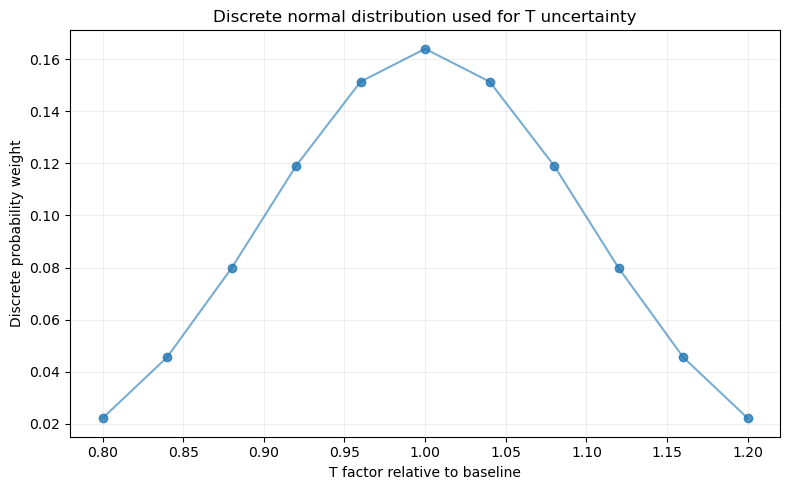

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_T_probability_weights.png


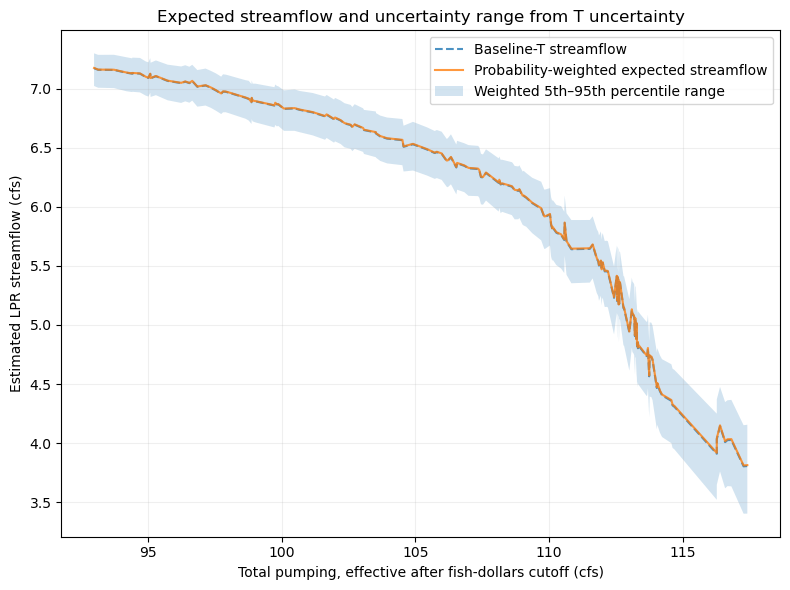

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_expected_streamflow_with_uncertainty_band.png


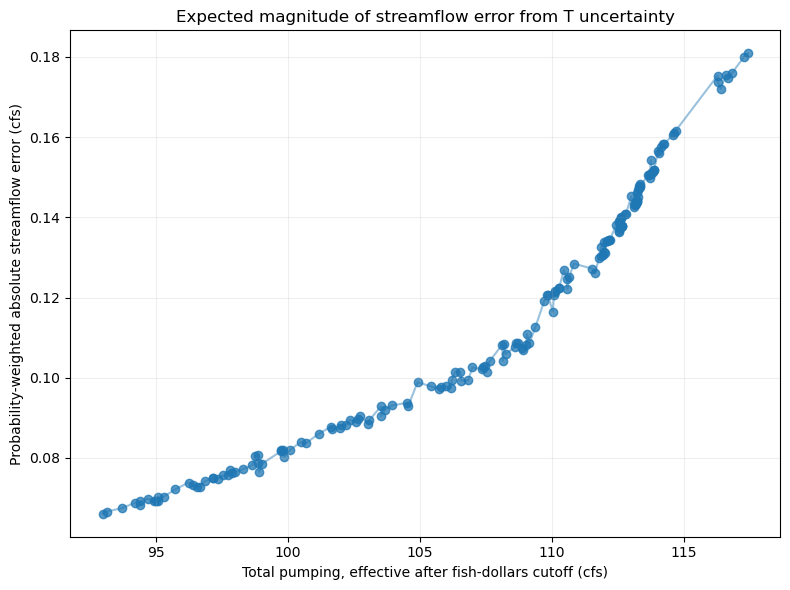

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_probability_weighted_absolute_streamflow_error.png


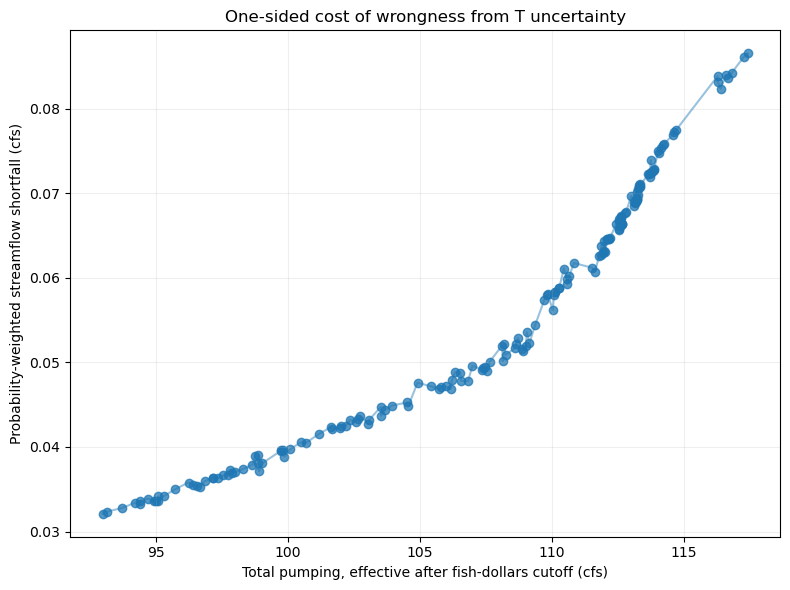

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_probability_weighted_streamflow_shortfall.png


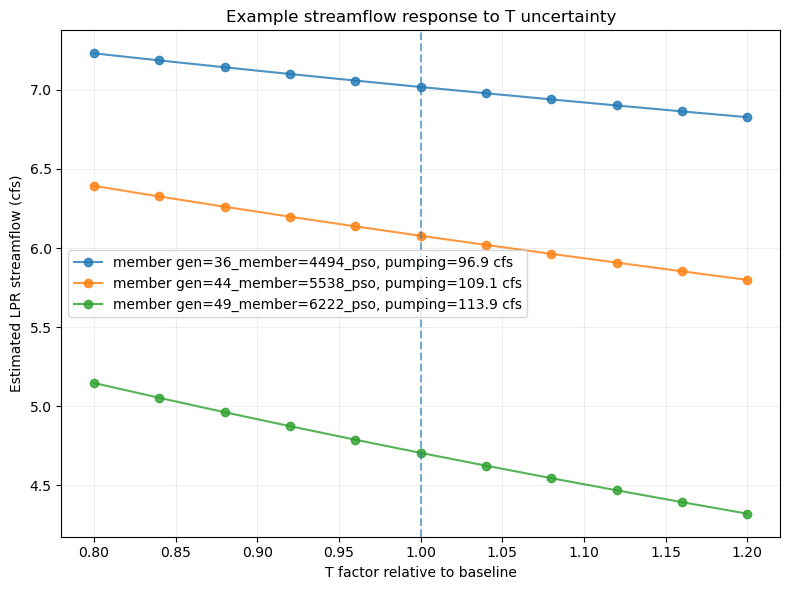

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_example_streamflow_response_curves.png


In [7]:
def sort_for_plot(df):
    return df.sort_values([PUMPING_COLUMN_FOR_HYDRO_PLOTS, "member"]).copy()


def save_current_fig(outfile):
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outfile)


# 1) Discrete T probability weights.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(T_probability_table["T_factor"], T_probability_table["probability_weight"], alpha=0.8)
ax.plot(T_probability_table["T_factor"], T_probability_table["probability_weight"], alpha=0.6)
ax.set_xlabel("T factor relative to baseline")
ax.set_ylabel("Discrete probability weight")
ax.set_title("Discrete normal distribution used for T uncertainty")
ax.grid(True, alpha=0.2)
save_current_fig(OUTPUT_DIR / "202_T_probability_weights.png")


# 2) Expected streamflow and uncertainty band.
plot_df = sort_for_plot(member_summary)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
    plot_df["baseline_T_streamflow_cfs"],
    linestyle="--",
    label="Baseline-T streamflow",
    alpha=0.8,
)
ax.plot(
    plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
    plot_df["expected_streamflow_cfs"],
    label="Probability-weighted expected streamflow",
    alpha=0.8,
)
ax.fill_between(
    plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
    plot_df["streamflow_p05_cfs"],
    plot_df["streamflow_p95_cfs"],
    alpha=0.2,
    label="Weighted 5th–95th percentile range",
)
ax.set_xlabel("Total pumping, effective after fish-dollars cutoff (cfs)")
ax.set_ylabel("Estimated LPR streamflow (cfs)")
ax.set_title("Expected streamflow and uncertainty range from T uncertainty")
ax.grid(True, alpha=0.2)
ax.legend()
save_current_fig(OUTPUT_DIR / "202_expected_streamflow_with_uncertainty_band.png")


# 3) Probability-weighted absolute streamflow error.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
    plot_df["probability_weighted_absolute_streamflow_error_cfs"],
    alpha=0.75,
)
ax.plot(
    plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
    plot_df["probability_weighted_absolute_streamflow_error_cfs"],
    alpha=0.45,
)
ax.set_xlabel("Total pumping, effective after fish-dollars cutoff (cfs)")
ax.set_ylabel("Probability-weighted absolute streamflow error (cfs)")
ax.set_title("Expected magnitude of streamflow error from T uncertainty")
ax.grid(True, alpha=0.2)
save_current_fig(OUTPUT_DIR / "202_probability_weighted_absolute_streamflow_error.png")


# 4) Probability-weighted one-sided streamflow shortfall.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
    plot_df["probability_weighted_streamflow_shortfall_cfs"],
    alpha=0.75,
)
ax.plot(
    plot_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS],
    plot_df["probability_weighted_streamflow_shortfall_cfs"],
    alpha=0.45,
)
ax.set_xlabel("Total pumping, effective after fish-dollars cutoff (cfs)")
ax.set_ylabel("Probability-weighted streamflow shortfall (cfs)")
ax.set_title("One-sided cost of wrongness from T uncertainty")
ax.grid(True, alpha=0.2)
save_current_fig(OUTPUT_DIR / "202_probability_weighted_streamflow_shortfall.png")


# 5) Example streamflow response curves for low, middle, and high pumping designs.
quantile_positions = [0.10, 0.50, 0.90]
example_members = []
for q in quantile_positions:
    idx = int(round(q * (len(plot_df) - 1)))
    example_members.append(plot_df.iloc[idx]["member"])
example_members = list(dict.fromkeys(example_members))

fig, ax = plt.subplots(figsize=(8, 6))
for member in example_members:
    member_df = results_long.loc[results_long["member"] == member].sort_values("T_factor")
    pumping = member_df[PUMPING_COLUMN_FOR_HYDRO_PLOTS].iloc[0]
    ax.plot(
        member_df["T_factor"],
        member_df["streamflow_cfs"],
        marker="o",
        alpha=0.8,
        label=f"member {member}, pumping={pumping:.1f} cfs",
    )
ax.axvline(1.0, linestyle="--", alpha=0.6)
ax.set_xlabel("T factor relative to baseline")
ax.set_ylabel("Estimated LPR streamflow (cfs)")
ax.set_title("Example streamflow response to T uncertainty")
ax.grid(True, alpha=0.2)
ax.legend()
save_current_fig(OUTPUT_DIR / "202_example_streamflow_response_curves.png")

## 8) Save outputs

In [8]:
results_long.to_csv(OUTPUT_DIR / "202_T_probability_reevaluation_long.csv", index=False)
member_summary.to_csv(OUTPUT_DIR / "202_probability_weighted_member_summary.csv", index=False)
scenario_summary.to_csv(OUTPUT_DIR / "202_T_probability_scenario_summary.csv", index=False)
T_probability_table.to_csv(OUTPUT_DIR / "202_T_probability_weights.csv", index=False)
overall_summary.to_csv(OUTPUT_DIR / "202_probability_weighted_overall_summary.csv", index=False)

if not error_df.empty:
    error_df.to_csv(OUTPUT_DIR / "202_T_probability_reevaluation_errors.csv", index=False)

print("Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f)

Saved files:
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_T_probability_reevaluation_long.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_T_probability_scenario_summary.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_T_probability_weights.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_T_probability_weights.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_example_streamflow_response_curves.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost/202_expected_streamflow_with_uncertainty_band.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/202_probability_weighted_T_uncertainty_cost

## 9) Interpretation guide

Use this notebook to support the **unknown T uncertainty** part of the project.

Recommended language for interpreting outputs:

- The baseline-T streamflow is what the model predicts if the built-in transmissivity is assumed correct.
- The T distribution represents uncertainty around that transmissivity.
- For each baseline Pareto design, the notebook recalculates streamflow under multiple possible true T values.
- The probability-weighted absolute streamflow error is the expected size of the streamflow prediction error caused by T uncertainty.
- The probability-weighted streamflow shortfall is a one-sided risk metric: it only counts cases where true streamflow is lower than the baseline-T prediction.

For your project narrative, the shortfall metric is useful because it answers:

> If I choose a pumping design assuming baseline T is correct, how much streamflow might I lose, in expectation, if true T is different?

This notebook does not select a new optimized Pareto front for each T. Instead, it evaluates the **same baseline Pareto designs** under uncertain T. That is intentional and matches the question: how robust are the original designs to transmissivity uncertainty?